In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [5]:
df = pd.read_csv("Coffee_Shop_Financial_Data_2023.csv")
df.head(10)

,Date,Category,Forecasted Amount,Actual Amount
0,2023-01-01,Coffee Sales,980,954
1,2023-01-01,Food Sales,646,703
2,2023-01-01,Ingredients Cost,457,447
3,2023-01-01,Labor,182,188
4,2023-01-01,Rent,384,375
5,2023-01-01,Utilities,489,534
6,2023-01-01,Marketing,125,125
7,2023-01-02,Coffee Sales,910,878
8,2023-01-02,Food Sales,418,399
9,2023-01-02,Ingredients Cost,349,352


In [6]:
df.isnull().sum()

Date                 0
Category             0
Forecasted Amount    0
Actual Amount        0
dtype: int64

In [8]:
df.shape


(2555, 4)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2555 entries, 0 to 2554
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Date               2555 non-null   object
 1   Category           2555 non-null   object
 2   Forecasted Amount  2555 non-null   int64 
 3   Actual Amount      2555 non-null   int64 
dtypes: int64(2), object(2)
memory usage: 80.0+ KB


In [11]:
df.describe()

,Forecasted Amount,Actual Amount
count,2555.000000,2555.000000
mean,382.334247,381.252446
std,206.698075,207.008455
min,100.000000,90.000000
25%,230.000000,229.000000
50%,344.000000,343.000000
75%,466.500000,463.000000
max,999.000000,1087.000000


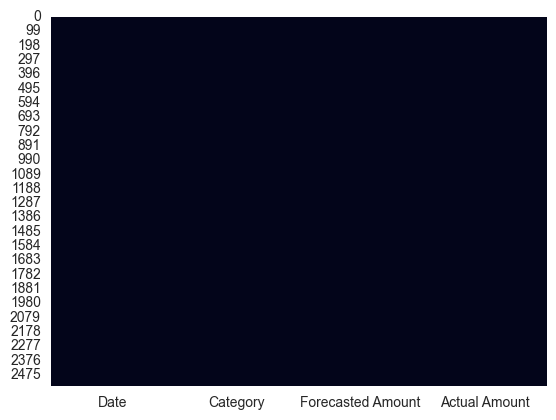

In [12]:
sns.heatmap(df.isnull(), cbar=False)
plt.show()

In [13]:
df.duplicated().sum()

np.int64(0)

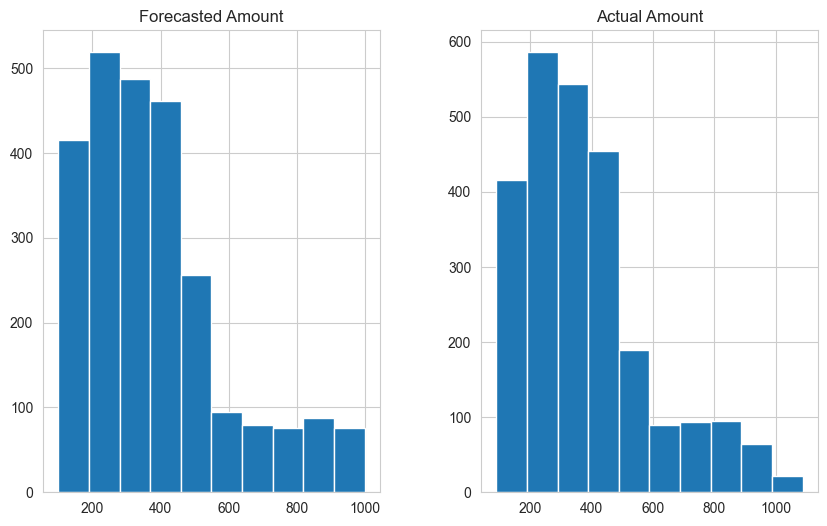

In [14]:
df.hist(figsize=(10,6))
plt.show()

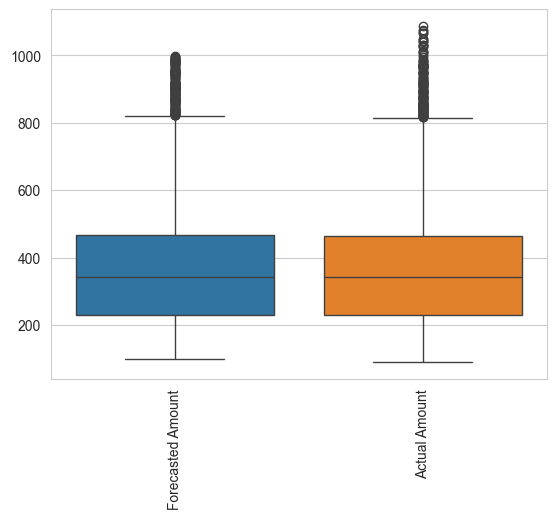

In [15]:
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

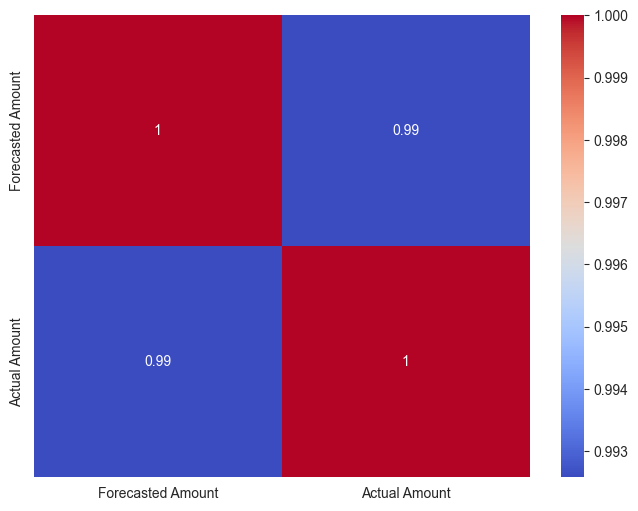

In [19]:
plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [21]:
# 1️⃣ Sirf numeric columns select karo
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# 2️⃣ IQR calculation
Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

# 3️⃣ Outliers detect karo
outliers = numeric_df[
    (numeric_df < (Q1 - 1.5 * IQR)) |
    (numeric_df > (Q3 + 1.5 * IQR))
]

outliers.count()

Forecasted Amount    163
Actual Amount        154
dtype: int64